In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import load_iris
import pandas as pd


iris = load_iris()


df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})


print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [3]:
df.drop(columns=['sepal length (cm)', 'sepal width (cm)'], inplace=True)


In [4]:
df.head(2)

,petal length (cm),petal width (cm),species
0,1.4,0.2,setosa
1,1.4,0.2,setosa


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [6]:
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(df[['petal length (cm)','petal width (cm)']])

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

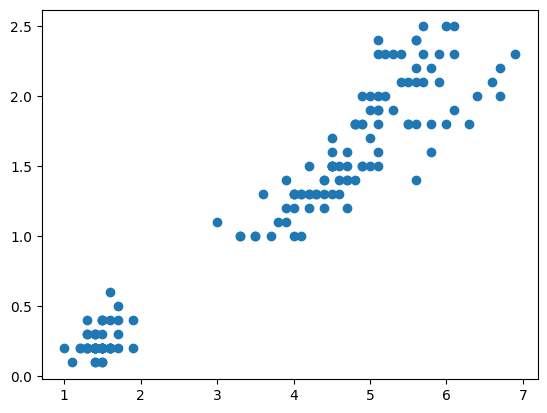

In [8]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])

In [9]:
df['Clusters'] = y_pred

In [10]:
df.head(250)

,petal length (cm),petal width (cm),species,Clusters
0,1.4,0.2,setosa,1
1,1.4,0.2,setosa,1
2,1.3,0.2,setosa,1
3,1.5,0.2,setosa,1
4,1.4,0.2,setosa,1
...,...,...,...,...
145,5.2,2.3,virginica,0
146,5.0,1.9,virginica,0
147,5.2,2.0,virginica,0
148,5.4,2.3,virginica,0


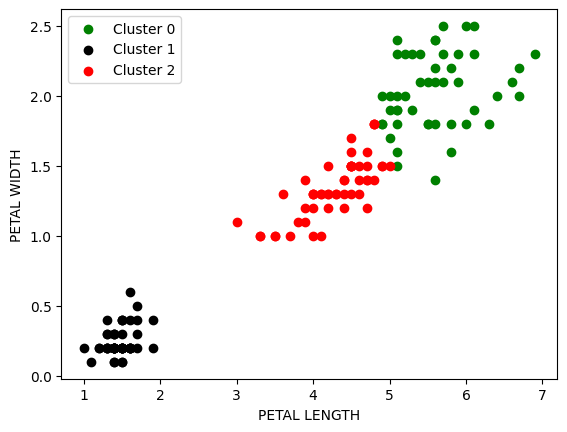

In [11]:
df1 = df[df['Clusters'] == 0]
df2 = df[df['Clusters'] == 1]
df3 = df[df['Clusters'] == 2]


import matplotlib.pyplot as plt

plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color='green', label='Cluster 0')
plt.scatter(df2['petal length (cm)'], df2['petal width (cm)'], color='black', label='Cluster 1')
plt.scatter(df3['petal length (cm)'], df3['petal width (cm)'], color='red', label='Cluster 2')


plt.xlabel('PETAL LENGTH')
plt.ylabel('PETAL WIDTH')
plt.legend()
plt.show()


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['petal length (cm)'] = scaler.fit_transform(df[['petal length (cm)']])
print(df)



     petal length (cm)  petal width (cm)    species  Clusters
0             0.067797               0.2     setosa         1
1             0.067797               0.2     setosa         1
2             0.050847               0.2     setosa         1
3             0.084746               0.2     setosa         1
4             0.067797               0.2     setosa         1
..                 ...               ...        ...       ...
145           0.711864               2.3  virginica         0
146           0.677966               1.9  virginica         0
147           0.711864               2.0  virginica         0
148           0.745763               2.3  virginica         0
149           0.694915               1.8  virginica         0

[150 rows x 4 columns]


In [13]:
scaler1 = MinMaxScaler()
df['petal width (cm)'] = scaler.fit_transform(df[['petal length (cm)']])
print(df)

     petal length (cm)  petal width (cm)    species  Clusters
0             0.067797          0.067797     setosa         1
1             0.067797          0.067797     setosa         1
2             0.050847          0.050847     setosa         1
3             0.084746          0.084746     setosa         1
4             0.067797          0.067797     setosa         1
..                 ...               ...        ...       ...
145           0.711864          0.711864  virginica         0
146           0.677966          0.677966  virginica         0
147           0.711864          0.711864  virginica         0
148           0.745763          0.745763  virginica         0
149           0.694915          0.694915  virginica         0

[150 rows x 4 columns]


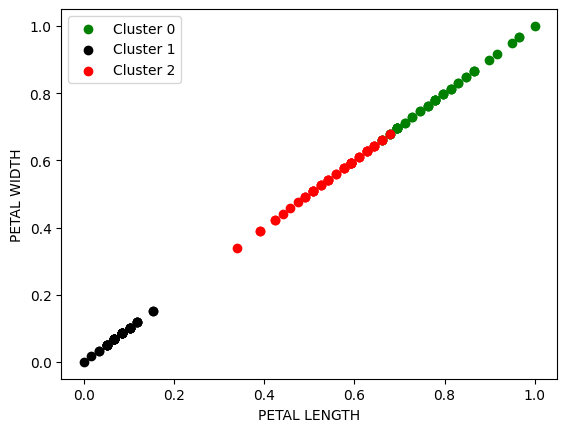

In [14]:
df1 = df[df['Clusters'] == 0]
df2 = df[df['Clusters'] == 1]
df3 = df[df['Clusters'] == 2]


import matplotlib.pyplot as plt

plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color='green', label='Cluster 0')
plt.scatter(df2['petal length (cm)'], df2['petal width (cm)'], color='black', label='Cluster 1')
plt.scatter(df3['petal length (cm)'], df3['petal width (cm)'], color='red', label='Cluster 2')


plt.xlabel('PETAL LENGTH')
plt.ylabel('PETAL WIDTH')
plt.legend()
plt.show()

In [15]:
k_rng = range(1,11)
sse = []
for i in k_rng:
    km = KMeans(n_clusters=i)
    km.fit(df[['petal length (cm)','petal width (cm)']])
    sse.append(km.inertia_)
    
    

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

In [16]:
sse

[26.67770180982476,
 3.8841557846576684,
 1.4085855351873366,
 0.7226378116122443,
 0.49958148091415694,
 0.34201666187877044,
 0.243841661379975,
 0.1959152216648996,
 0.15633977723894404,
 0.12150719743534517]

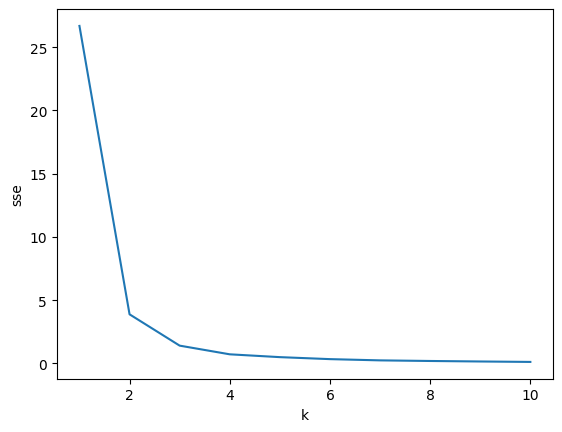

In [17]:
plt.xlabel('k')
plt.ylabel('sse')
plt.plot(k_rng,sse)

In [18]:
km.cluster_centers_

array([[0.51483051, 0.51483051],
       [0.06550618, 0.06550618],
       [0.78165503, 0.78165503],
       [0.6970339 , 0.6970339 ],
       [0.58823529, 0.58823529],
       [0.95932203, 0.95932203],
       [0.40920097, 0.40920097],
       [0.8559322 , 0.8559322 ],
       [0.11473272, 0.11473272],
       [0.6440678 , 0.6440678 ]])